In [1]:
import matplotlib.pyplot as plt
import numpy as np
import math
import pandas as pd
import numpy as np
import torch
import torch.optim as optim
from variables import *
from ref import *
from read_complex_matrix import read_complex_matrix
from calculating_dynamic_resolution import *
torch.set_printoptions(precision=4)

matr = read_complex_matrix('ref_matrix.txt')
import timeit

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [2]:
data = np.loadtxt('experiment.txt')

r = data[:, 1]
r2 = data[:, 1] + data[:, 2]
r1 = data[:, 1] - data[:, 2]
sigma = sigma+0.0
Ibkg=Ibkg+0.0
I0_plus = np.mean(r[r > 0.9*r1[0]][0:1+math.ceil(len(r[r > 0.9*r1[0]])*0.7)])
I0 = torch.tensor(I0_plus).requires_grad_(True) - Ibkg

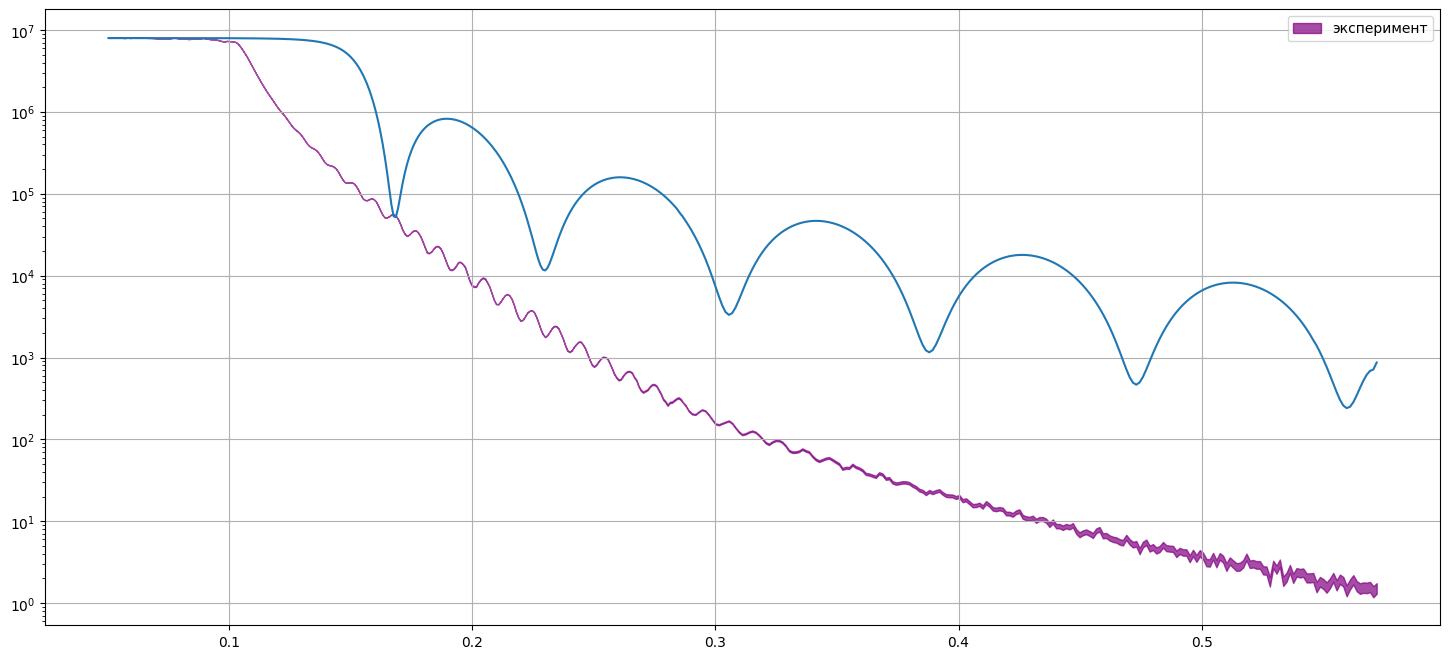

In [3]:
q = 2.0e+10*torch.sin(torch.tensor(torch.pi*data[:, 0]/180))/1.524
r_mod, r_mod_conv= reflectometry(q, matr, sigma, sigma, I0, Ibkg)

fig, ax = plt.subplots(figsize=(18, 8))

ax.fill_between(q*1e-9, r1, r2, color='purple', alpha=0.7, label= 'эксперимент')
ax.plot(q.cpu().detach().numpy()[0:len(r_mod_conv.tolist())]*1e-9, (I0*r_mod_conv).tolist())
ax.set_yscale('log')

ax.legend()
plt.grid()
plt.show()

In [4]:
r = torch.tensor(data[:, 1], requires_grad = True)/I0
len(r)

467

In [5]:
from objective_function import *

loss_function = Comparator(q, matr, 10*sigma, 6*sigma, I0, Ibkg)

objective_function = varbounds(all_bounds, loss_function.compare)
objective_function_weightless = varbounds(all_bounds, loss_function.compare_weightless)

In [6]:
initial_d = torch.tensor([700.0,  15.0, 20.0,  0.0], requires_grad=True)
initial_rho = torch.tensor([4.02,  0.576], requires_grad=True)
initial_sigma = torch.tensor(0.01, requires_grad=True)

I_bounds =  torch.tensor([0.92*I0 , 1.08*I0]).requires_grad_(True)
Ibkg_bounds = torch.tensor([0.0, 3*Ibkg]).requires_grad_(True)

initial_sigma1 = torch.nn.Parameter(torch.tensor(0.01, dtype=torch.float64))
initial_sigma2 = torch.nn.Parameter(torch.tensor(0.01, dtype=torch.float64))
sigma_bounds1 =  torch.tensor([0.005 , 0.03]).requires_grad_(True)
sigma_bounds2 =  torch.tensor([0.005 , 0.03]).requires_grad_(True)

In [7]:
objective_function_weightless.objective_function(initial_d, initial_rho, sigma1, sigma2, I0, Ibkg)

tensor(22.2801, dtype=torch.float64, grad_fn=<SumBackward0>)

In [8]:
objective_function.objective_function(initial_d, initial_rho, sigma1, sigma2, I0, Ibkg)

tensor(0.0527, dtype=torch.float64, grad_fn=<SumBackward0>)

relative_loss:   1.0 
 d:   tensor([695.0000,  20.0000,  15.0002,  16.0000])     grad_d:   tensor([ 0.0018, -0.0014,  0.0003,  0.0007]) 
 rho:   tensor([4.0250, 0.5710])     grad_rho:   tensor([-0.0471,  0.0093]) 
 sigma1:   tensor(0.0106, dtype=torch.float64)     grad_sigma1:   tensor(-0.1237, dtype=torch.float64, grad_fn=<DivBackward0>) 
 sigma2:   tensor(0.0100, dtype=torch.float64)     grad_sigma2:   tensor(0., dtype=torch.float64, grad_fn=<DivBackward0>) 
 I:   tensor(7885190.3296, dtype=torch.float64)     grad_I:   tensor(1.6711e-14, dtype=torch.float64) 
 Ibkg:   tensor(1.1924, dtype=torch.float64)     grad_Ibkg:   tensor(-1.2106e-07, dtype=torch.float64) 
 learning_rate:   5.0 
 iteration:   1 



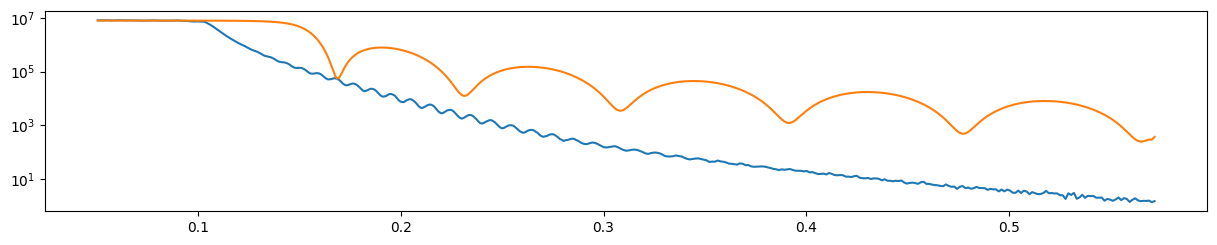

relative_loss:   0.572372565709219 
 d:   tensor([6.5872e+02, 1.3775e+01, 1.6613e-01, 1.6000e+01])     grad_d:   tensor([ 2.1210e-05,  1.8924e-05, -8.1968e-07,  1.2275e-05]) 
 rho:   tensor([4.0100, 0.5619])     grad_rho:   tensor([ 1.6533e-01, -2.1713e-05]) 
 sigma1:   tensor(0.0189, dtype=torch.float64)     grad_sigma1:   tensor(0.0099, dtype=torch.float64, grad_fn=<DivBackward0>) 
 sigma2:   tensor(0.0100, dtype=torch.float64)     grad_sigma2:   tensor(0., dtype=torch.float64, grad_fn=<DivBackward0>) 
 I:   tensor(7331244.8710, dtype=torch.float64)     grad_I:   tensor(1.0340e-13, dtype=torch.float64) 
 Ibkg:   tensor(3.3000, dtype=torch.float64)     grad_Ibkg:   tensor(-2.2972e-07, dtype=torch.float64) 
 learning_rate:   3.234950917245001 
 iteration:   60 



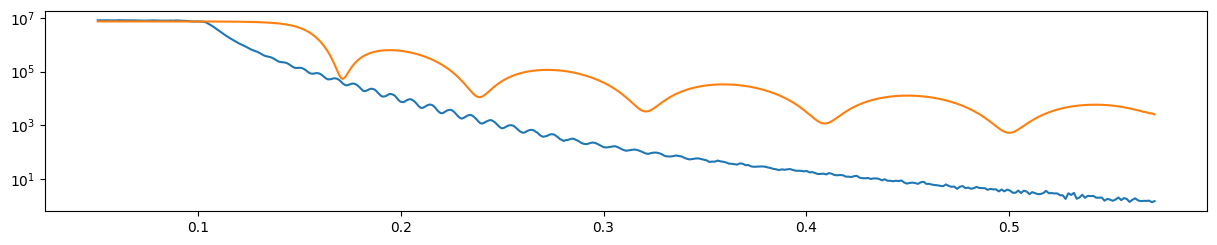

relative_loss:   0.5695444178009285 
 d:   tensor([648.9847,   2.6707,   5.8385,  16.0000])     grad_d:   tensor([ 4.4330e-06,  3.6975e-06, -4.5681e-07,  4.4695e-06]) 
 rho:   tensor([4.0100, 0.5644])     grad_rho:   tensor([ 1.6293e-01, -5.4950e-06]) 
 sigma1:   tensor(0.0190, dtype=torch.float64)     grad_sigma1:   tensor(0.0005, dtype=torch.float64, grad_fn=<DivBackward0>) 
 sigma2:   tensor(0.0100, dtype=torch.float64)     grad_sigma2:   tensor(0., dtype=torch.float64, grad_fn=<DivBackward0>) 
 I:   tensor(7331244.8710, dtype=torch.float64)     grad_I:   tensor(1.0538e-13, dtype=torch.float64) 
 Ibkg:   tensor(3.3000, dtype=torch.float64)     grad_Ibkg:   tensor(-2.3412e-07, dtype=torch.float64) 
 learning_rate:   2.250517728383714 
 iteration:   119 



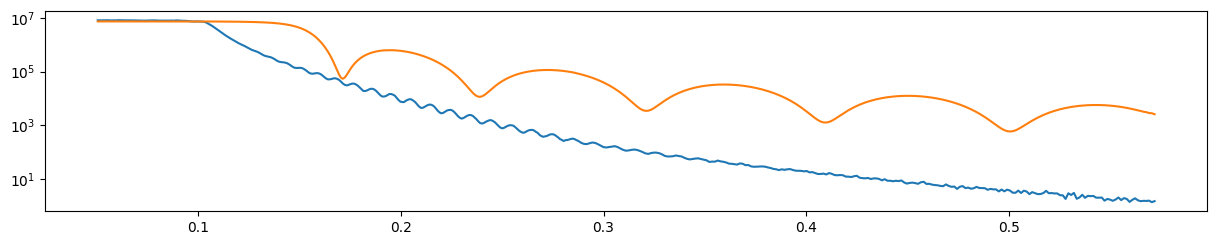

In [9]:
from optimizer import *
ans_d, ans_rho, ans_sigma1, ans_sigma2, ans_I, ans_Ibkg, loss, rel_losses1 = adamw(q, r, objective_function.objective_function, 
                                                                      initial_d, initial_rho, initial_sigma1, initial_sigma2, 1.0*I0, Ibkg, 
                                                                      d_bounds, rho_bounds, sigma_bounds1, sigma_bounds2, I_bounds, Ibkg_bounds,
                                                                      lr= 0.005, max_iter = 120, k=3)



relative_loss:   1.0 
 d:   tensor([649.7057,   1.7828,   6.6963,  16.8000])     grad_d:   tensor([-4.8840,  3.9681, -0.5801, -2.2604]) 
 rho:   tensor([4.0100, 0.5636])     grad_rho:   tensor([223.6706,   2.4024]) 
 sigma1:   tensor(0.0050, dtype=torch.float64)     grad_sigma1:   tensor(531.4642, dtype=torch.float64, grad_fn=<DivBackward0>) 
 sigma2:   tensor(0.0100, dtype=torch.float64)     grad_sigma2:   tensor(0., dtype=torch.float64, grad_fn=<DivBackward0>) 
 I:   tensor(8606243.9790, dtype=torch.float64)     grad_I:   tensor(-9.4023e-09, dtype=torch.float64) 
 Ibkg:   tensor(3.2840, dtype=torch.float64)     grad_Ibkg:   tensor(0.0209, dtype=torch.float64) 
 learning_rate:   0.8 
 iteration:   1 



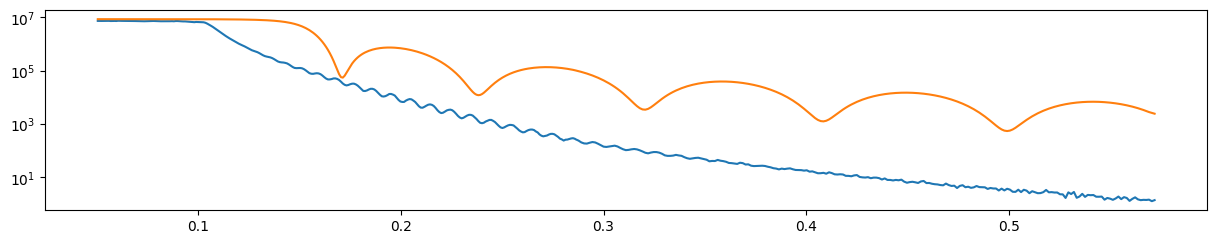

relative_loss:   0.3904220797952696 
 d:   tensor([668.6182,   1.0000,  20.7589,  28.0000])     grad_d:   tensor([-0.2141,  0.1839,  0.0468, -0.0621]) 
 rho:   tensor([4.0101, 0.5853])     grad_rho:   tensor([-1.8538, -0.2292]) 
 sigma1:   tensor(0.0300, dtype=torch.float64)     grad_sigma1:   tensor(-494.6280, dtype=torch.float64, grad_fn=<DivBackward0>) 
 sigma2:   tensor(0.0100, dtype=torch.float64)     grad_sigma2:   tensor(0., dtype=torch.float64, grad_fn=<DivBackward0>) 
 I:   tensor(7331244.8710, dtype=torch.float64)     grad_I:   tensor(7.1777e-09, dtype=torch.float64) 
 Ibkg:   tensor(3.3000, dtype=torch.float64)     grad_Ibkg:   tensor(-0.0159, dtype=torch.float64) 
 learning_rate:   0.5175921467592002 
 iteration:   62 



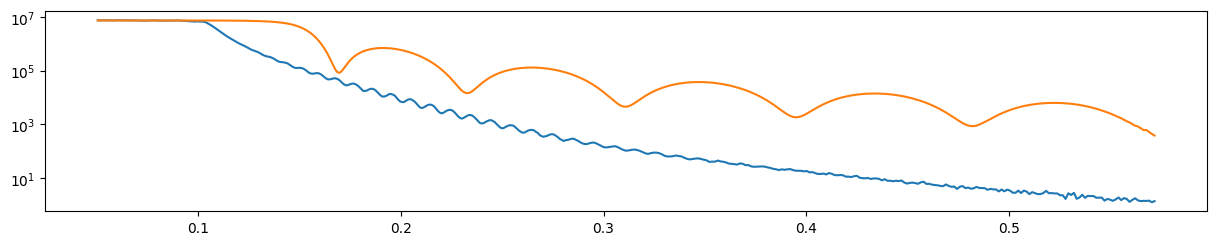

relative_loss:   0.38518103988211316 
 d:   tensor([671.8083,   1.0000,  14.9716,  27.4868])     grad_d:   tensor([-0.0626,  0.0673,  0.0144,  0.0268]) 
 rho:   tensor([4.0129, 0.5937])     grad_rho:   tensor([-4.4763, -0.2523]) 
 sigma1:   tensor(0.0300, dtype=torch.float64)     grad_sigma1:   tensor(-506.6417, dtype=torch.float64, grad_fn=<DivBackward0>) 
 sigma2:   tensor(0.0100, dtype=torch.float64)     grad_sigma2:   tensor(0., dtype=torch.float64, grad_fn=<DivBackward0>) 
 I:   tensor(7331244.8710, dtype=torch.float64)     grad_I:   tensor(7.5742e-09, dtype=torch.float64) 
 Ibkg:   tensor(3.3000, dtype=torch.float64)     grad_Ibkg:   tensor(-0.0168, dtype=torch.float64) 
 learning_rate:   0.3348770379834968 
 iteration:   123 



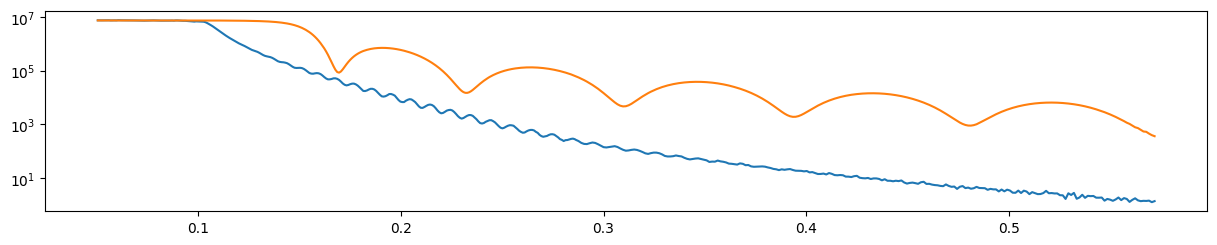

relative_loss:   0.38350602949563106 
 d:   tensor([673.5905,   1.0000,  12.8926,  25.0626])     grad_d:   tensor([-0.0445,  0.0539,  0.0059,  0.0313]) 
 rho:   tensor([4.0164, 0.6028])     grad_rho:   tensor([-3.0410, -0.2059]) 
 sigma1:   tensor(0.0300, dtype=torch.float64)     grad_sigma1:   tensor(-510.8780, dtype=torch.float64, grad_fn=<DivBackward0>) 
 sigma2:   tensor(0.0100, dtype=torch.float64)     grad_sigma2:   tensor(0., dtype=torch.float64, grad_fn=<DivBackward0>) 
 I:   tensor(7331244.8710, dtype=torch.float64)     grad_I:   tensor(7.5119e-09, dtype=torch.float64) 
 Ibkg:   tensor(3.3000, dtype=torch.float64)     grad_Ibkg:   tensor(-0.0167, dtype=torch.float64) 
 learning_rate:   0.2166621562378004 
 iteration:   184 



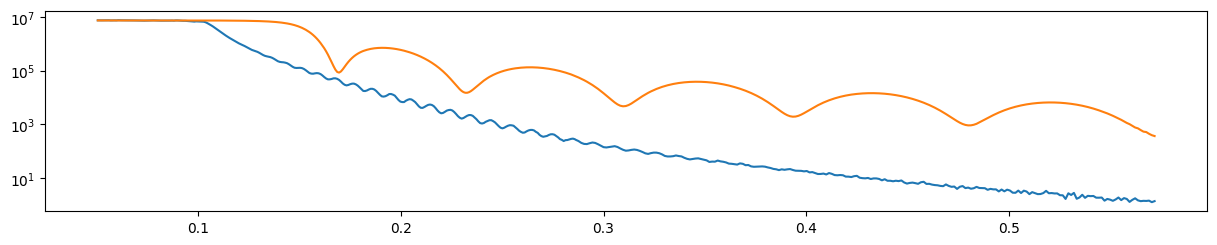

relative_loss:   0.38216197107585725 
 d:   tensor([675.2459,   1.0000,  11.4195,  22.3189])     grad_d:   tensor([-0.0359,  0.0478,  0.0047,  0.0277]) 
 rho:   tensor([4.0189, 0.6097])     grad_rho:   tensor([-1.6396, -0.1558]) 
 sigma1:   tensor(0.0300, dtype=torch.float64)     grad_sigma1:   tensor(-513.7259, dtype=torch.float64, grad_fn=<DivBackward0>) 
 sigma2:   tensor(0.0100, dtype=torch.float64)     grad_sigma2:   tensor(0., dtype=torch.float64, grad_fn=<DivBackward0>) 
 I:   tensor(7331244.8710, dtype=torch.float64)     grad_I:   tensor(7.4196e-09, dtype=torch.float64) 
 Ibkg:   tensor(3.3000, dtype=torch.float64)     grad_Ibkg:   tensor(-0.0165, dtype=torch.float64) 
 learning_rate:   0.14017828821075043 
 iteration:   245 



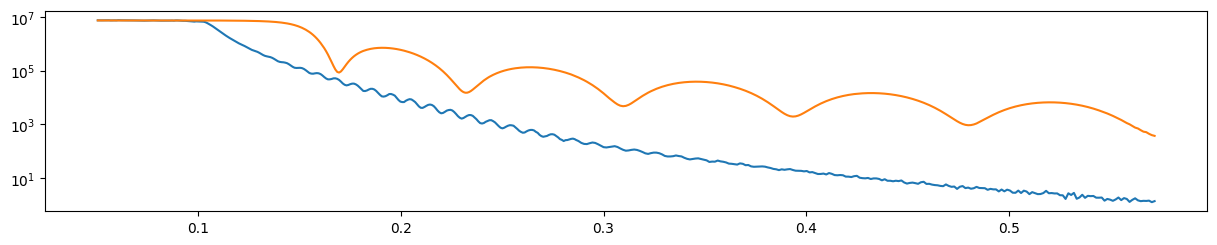

relative_loss:   0.38109756408731166 
 d:   tensor([676.8000,   1.0000,  10.0029,  19.6223])     grad_d:   tensor([-0.0285,  0.0426,  0.0039,  0.0244]) 
 rho:   tensor([4.0204, 0.6144])     grad_rho:   tensor([-0.6583, -0.1157]) 
 sigma1:   tensor(0.0300, dtype=torch.float64)     grad_sigma1:   tensor(-515.8235, dtype=torch.float64, grad_fn=<DivBackward0>) 
 sigma2:   tensor(0.0100, dtype=torch.float64)     grad_sigma2:   tensor(0., dtype=torch.float64, grad_fn=<DivBackward0>) 
 I:   tensor(7331244.8710, dtype=torch.float64)     grad_I:   tensor(7.3399e-09, dtype=torch.float64) 
 Ibkg:   tensor(3.3000, dtype=torch.float64)     grad_Ibkg:   tensor(-0.0163, dtype=torch.float64) 
 learning_rate:   0.09069397640504023 
 iteration:   306 



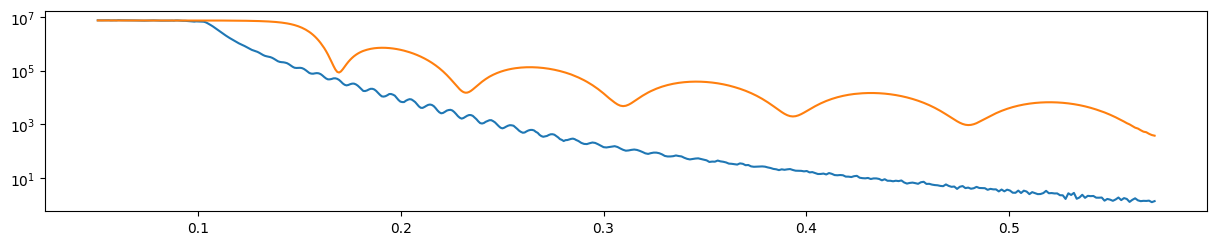

relative_loss:   0.38029147801113034 
 d:   tensor([678.1857,   1.0000,   8.6839,  17.1484])     grad_d:   tensor([-0.0218,  0.0378,  0.0031,  0.0219]) 
 rho:   tensor([4.0209, 0.6175])     grad_rho:   tensor([-0.0914, -0.0858]) 
 sigma1:   tensor(0.0300, dtype=torch.float64)     grad_sigma1:   tensor(-517.2922, dtype=torch.float64, grad_fn=<DivBackward0>) 
 sigma2:   tensor(0.0100, dtype=torch.float64)     grad_sigma2:   tensor(0., dtype=torch.float64, grad_fn=<DivBackward0>) 
 I:   tensor(7331244.8710, dtype=torch.float64)     grad_I:   tensor(7.2798e-09, dtype=torch.float64) 
 Ibkg:   tensor(3.3000, dtype=torch.float64)     grad_Ibkg:   tensor(-0.0162, dtype=torch.float64) 
 learning_rate:   0.05867811243201627 
 iteration:   367 



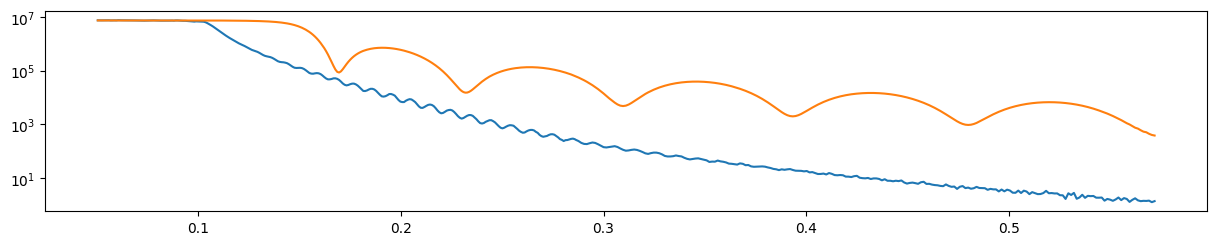

relative_loss:   0.3799229839098162 
 d:   tensor([679.0990,   1.0000,   7.6278,  16.0000])     grad_d:   tensor([-0.0031,  0.0234,  0.0010,  0.0295]) 
 rho:   tensor([4.0211, 0.6196])     grad_rho:   tensor([-0.3918, -0.0740]) 
 sigma1:   tensor(0.0300, dtype=torch.float64)     grad_sigma1:   tensor(-519.8687, dtype=torch.float64, grad_fn=<DivBackward0>) 
 sigma2:   tensor(0.0100, dtype=torch.float64)     grad_sigma2:   tensor(0., dtype=torch.float64, grad_fn=<DivBackward0>) 
 I:   tensor(7331244.8710, dtype=torch.float64)     grad_I:   tensor(7.3139e-09, dtype=torch.float64) 
 Ibkg:   tensor(3.3000, dtype=torch.float64)     grad_Ibkg:   tensor(-0.0162, dtype=torch.float64) 
 learning_rate:   0.037964162726831265 
 iteration:   428 



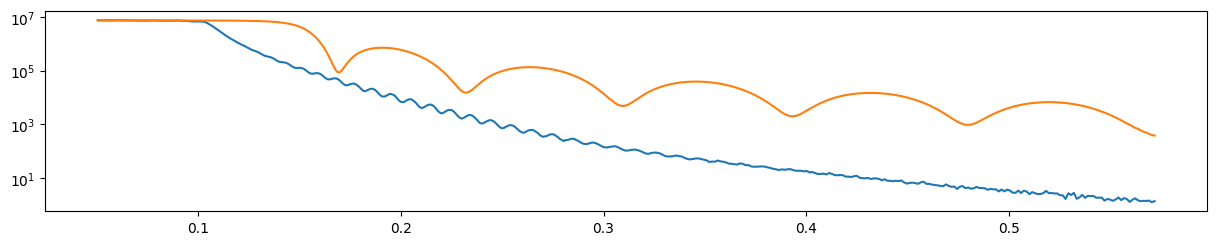

relative_loss:   0.3799183963274535 
 d:   tensor([679.1782,   1.0000,   7.4903,  16.0000])     grad_d:   tensor([-3.2309e-04,  2.1288e-02,  2.4349e-05,  3.1161e-02]) 
 rho:   tensor([4.0218, 0.6212])     grad_rho:   tensor([-0.2552, -0.0739]) 
 sigma1:   tensor(0.0300, dtype=torch.float64)     grad_sigma1:   tensor(-520.5631, dtype=torch.float64, grad_fn=<DivBackward0>) 
 sigma2:   tensor(0.0100, dtype=torch.float64)     grad_sigma2:   tensor(0., dtype=torch.float64, grad_fn=<DivBackward0>) 
 I:   tensor(7331244.8710, dtype=torch.float64)     grad_I:   tensor(7.3205e-09, dtype=torch.float64) 
 Ibkg:   tensor(3.3000, dtype=torch.float64)     grad_Ibkg:   tensor(-0.0163, dtype=torch.float64) 
 learning_rate:   0.024562440607120255 
 iteration:   489 



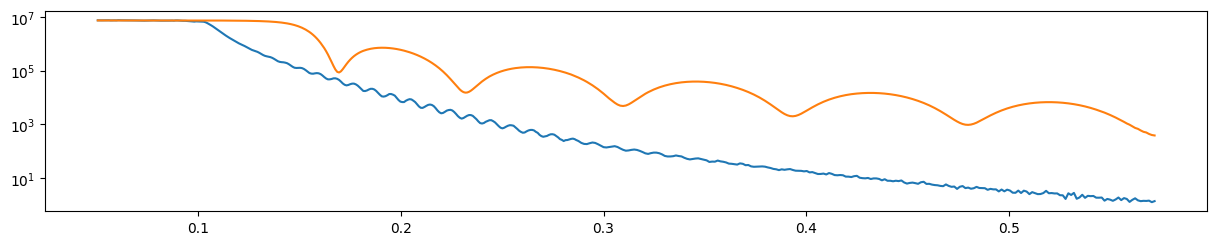

relative_loss:   0.3799170352730412 
 d:   tensor([679.1954,   1.0000,   7.4852,  16.0000])     grad_d:   tensor([-1.3060e-04,  2.1159e-02,  2.5272e-06,  3.1168e-02]) 
 rho:   tensor([4.0222, 0.6223])     grad_rho:   tensor([-0.1228, -0.0737]) 
 sigma1:   tensor(0.0300, dtype=torch.float64)     grad_sigma1:   tensor(-520.7944, dtype=torch.float64, grad_fn=<DivBackward0>) 
 sigma2:   tensor(0.0100, dtype=torch.float64)     grad_sigma2:   tensor(0., dtype=torch.float64, grad_fn=<DivBackward0>) 
 I:   tensor(7331244.8710, dtype=torch.float64)     grad_I:   tensor(7.3188e-09, dtype=torch.float64) 
 Ibkg:   tensor(3.3000, dtype=torch.float64)     grad_Ibkg:   tensor(-0.0163, dtype=torch.float64) 
 learning_rate:   0.014779241897550994 
 iteration:   550 



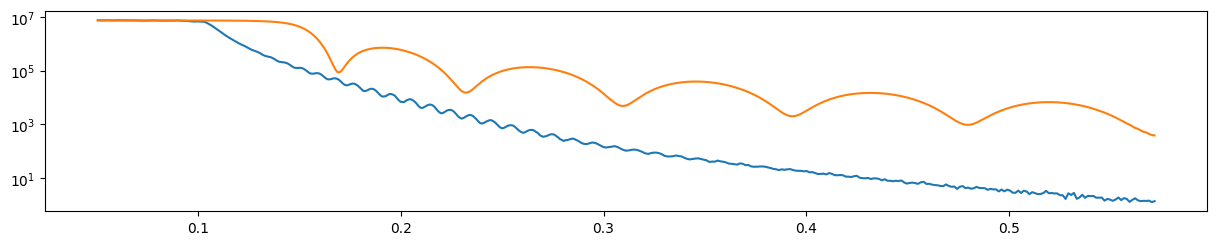

relative_loss:   0.3799164189928909 
 d:   tensor([679.2039,   1.0000,   7.4838,  16.0000])     grad_d:   tensor([-4.3168e-05,  2.1101e-02,  2.8340e-06,  3.1159e-02]) 
 rho:   tensor([4.0224, 0.6231])     grad_rho:   tensor([-0.0539, -0.0736]) 
 sigma1:   tensor(0.0300, dtype=torch.float64)     grad_sigma1:   tensor(-520.9124, dtype=torch.float64, grad_fn=<DivBackward0>) 
 sigma2:   tensor(0.0100, dtype=torch.float64)     grad_sigma2:   tensor(0., dtype=torch.float64, grad_fn=<DivBackward0>) 
 I:   tensor(7331244.8710, dtype=torch.float64)     grad_I:   tensor(7.3179e-09, dtype=torch.float64) 
 Ibkg:   tensor(3.3000, dtype=torch.float64)     grad_Ibkg:   tensor(-0.0163, dtype=torch.float64) 
 learning_rate:   0.009562024426533667 
 iteration:   611 



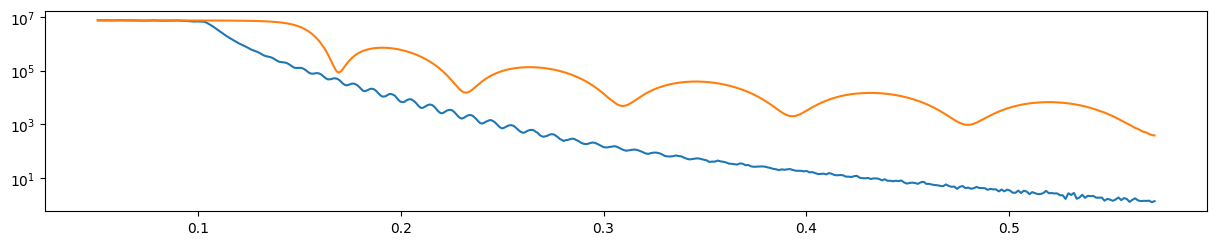

relative_loss:   0.37991609005469695 
 d:   tensor([679.2079,   1.0000,   7.4831,  16.0000])     grad_d:   tensor([-1.2883e-05,  2.1083e-02,  1.0804e-06,  3.1148e-02]) 
 rho:   tensor([4.0225, 0.6236])     grad_rho:   tensor([-0.0207, -0.0736]) 
 sigma1:   tensor(0.0300, dtype=torch.float64)     grad_sigma1:   tensor(-520.9670, dtype=torch.float64, grad_fn=<DivBackward0>) 
 sigma2:   tensor(0.0100, dtype=torch.float64)     grad_sigma2:   tensor(0., dtype=torch.float64, grad_fn=<DivBackward0>) 
 I:   tensor(7331244.8710, dtype=torch.float64)     grad_I:   tensor(7.3174e-09, dtype=torch.float64) 
 Ibkg:   tensor(3.3000, dtype=torch.float64)     grad_Ibkg:   tensor(-0.0163, dtype=torch.float64) 
 learning_rate:   0.006186535937866838 
 iteration:   672 



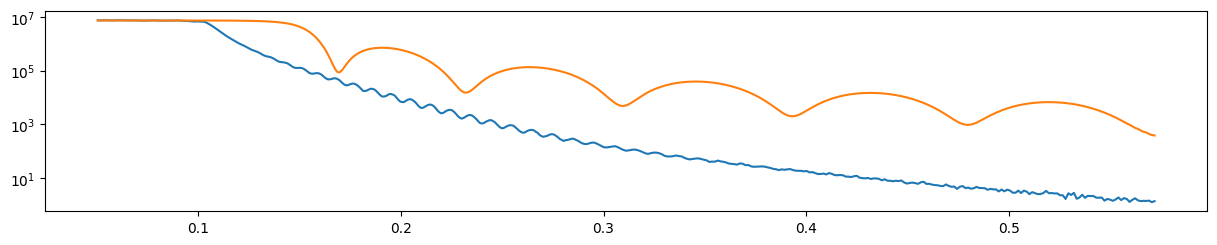

In [10]:
ans_d, ans_rho, ans_sigma1, ans_sigma2, ans_I, ans_Ibkg, loss, rel_losses2 = adamw(q, r, objective_function_weightless.objective_function, 
                                                                      ans_d, ans_rho, ans_sigma1, ans_sigma2, ans_I, ans_Ibkg, 
                                                                      d_bounds, rho_bounds, sigma_bounds1, sigma_bounds2, I_bounds, Ibkg_bounds,
                                                                      lr= 0.0008, max_iter = 680, k=12)


In [11]:
rel_losses2 = list(map(lambda x: x * rel_losses1[-1],  rel_losses2))
rel_losses3 = rel_losses1 + rel_losses2

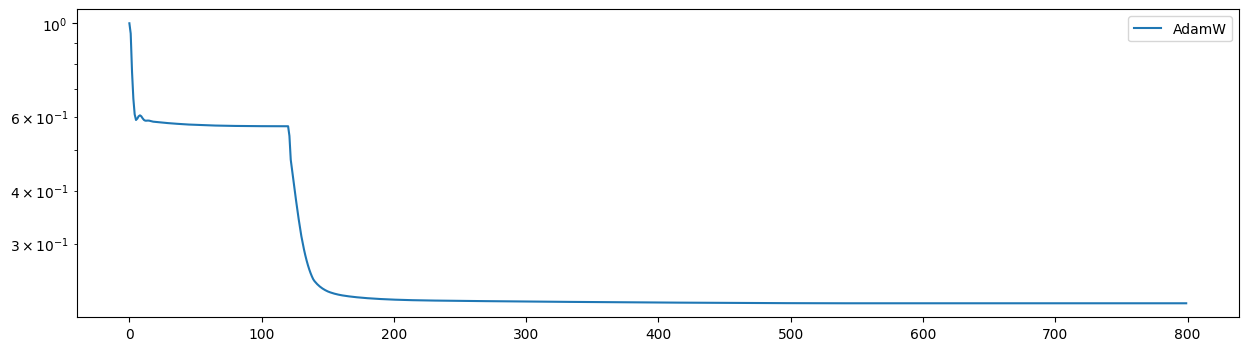

In [12]:
fig, ax = plt.subplots(figsize =(15, 4))

ax.plot(range(0,len(rel_losses3)), rel_losses3, label='AdamW')

ax.set_yscale('log')
ax.legend()
plt.show()